# **Лабораторная работа №2 "ОБнаружение аномалий и выбросов в данных"**

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37784 entries, 0 to 37783
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   RoundID        37784 non-null  int64 
 1   MatchID        37784 non-null  int64 
 2   Team Initials  37784 non-null  object
 3   Coach Name     37784 non-null  object
 4   Line-up        37784 non-null  object
 5   Shirt Number   37784 non-null  int64 
 6   Player Name    37784 non-null  object
 7   Position       4143 non-null   object
 8   Event          9069 non-null   object
dtypes: int64(3), object(6)
memory usage: 2.6+ MB

--- df.describe() ---
             RoundID       MatchID Team Initials                 Coach Name  \
count   3.778400e+04  3.778400e+04         37784                      37784   
unique           NaN           NaN            82                        335   
top              NaN           NaN           BRA  SCOLARI Luiz Felipe (BRA)   
freq        

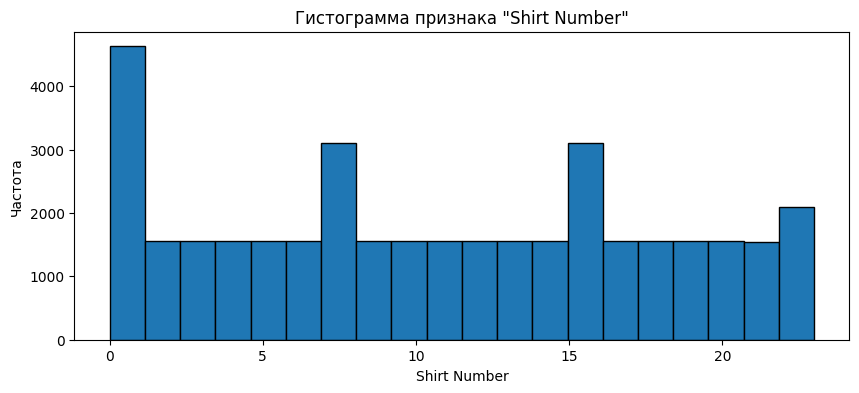

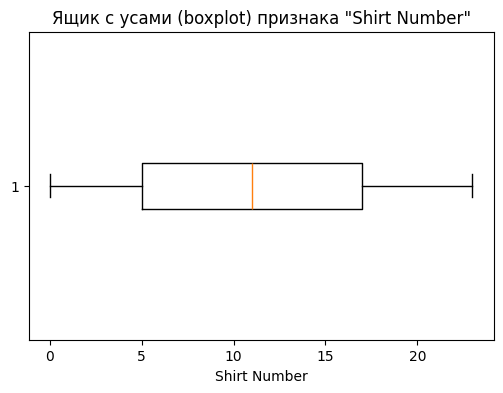

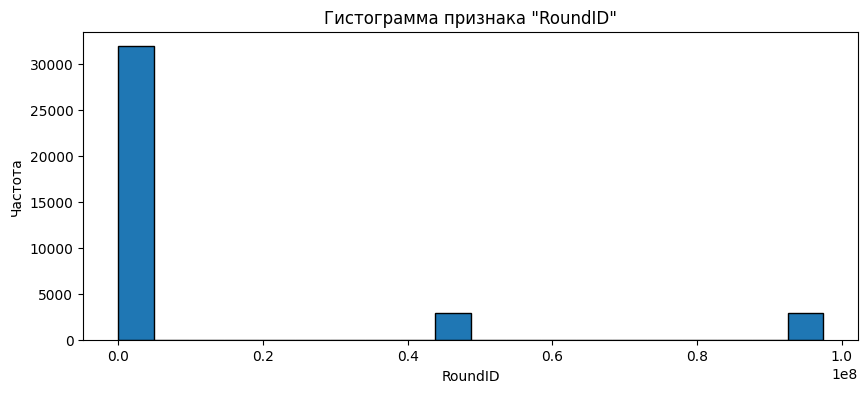

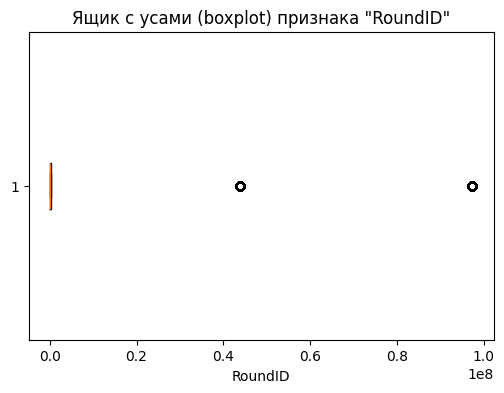

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('WorldCupPlayers.csv')


print('--- df.info() ---')
df.info()

print('\n--- df.describe() ---')
print(df.describe(include='all'))


print('\n--- Пропуски в каждом столбце ---')
missing = df.isnull().sum()
print(missing[missing > 0])


print('\n--- Диапазоны числовых признаков ---')
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    print(f'{col}: от {df[col].min()} до {df[col].max()}')


print('\n--- Проверка номеров игроков ---')
outliers = df[~df['Shirt Number'].between(1, 22)]['Shirt Number'].unique()
print(f'Номера вне диапазона 1–22: {sorted(outliers)}')
print('(Значение 0 встречается в старых данных и не считается ошибкой)')


features = ['Shirt Number', 'RoundID']
for feat in features:

    plt.figure(figsize=(10, 4))
    plt.hist(df[feat].dropna(), bins=20, edgecolor='black')
    plt.title(f'Гистограмма признака "{feat}"')
    plt.xlabel(feat)
    plt.ylabel('Частота')
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.boxplot(df[feat].dropna(), vert=False)
    plt.title(f'Ящик с усами (boxplot) признака "{feat}"')
    plt.xlabel(feat)
    plt.show()



- Shirt Number:
  * Гистограмма показывает, что большинство значений сосредоточено в диапазоне 1–22.
  * Boxplot выявляет наличие нулевых значений (0) – они формально являются выбросами,
    но исторически в первых чемпионатах мира номера не были фиксированы,
    поэтому 0 можно считать допустимым значением.
  * Других аномалий не обнаружено.

- RoundID:
  * Это идентификатор раунда, значения распределены неравномерно, но это ожидаемо.
  * Boxplot не показывает статистических выбросов, так как все значения лежат
    в пределах диапазона данных.

Задание 2. Проверка нормальности распределения

ЗАДАНИЕ 2. ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ

--- Описательные характеристики для Shirt Number ---
Среднее (mean):                 10.7260
Медиана (median):               11.0000
Стандартное отклонение (std):   6.9601
Коэффициент асимметрии (skew):  0.0321
Коэффициент эксцесса (kurtosis):-1.2267
  → Асимметрия положительная (хвост справа)
  → Эксцесс отрицательный (распределение более плоское)

--- Описательные характеристики для RoundID ---
Среднее (mean):                 11056474.4460
Медиана (median):               337.0000
Стандартное отклонение (std):   27701436.5284
Коэффициент асимметрии (skew):  2.4372
Коэффициент эксцесса (kurtosis):4.5323
  → Асимметрия положительная (хвост справа)
  → Эксцесс положительный (распределение острее нормального)

--- QQ-графики (сравнение с нормальным распределением) ---


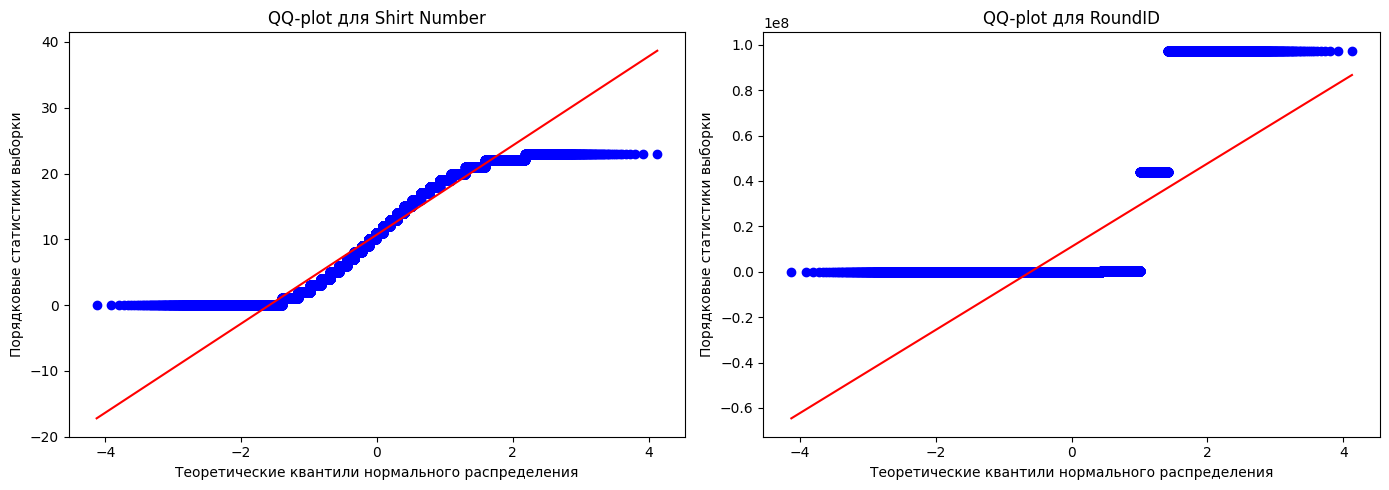


Анализ QQ-графиков:
• Если точки лежат близко к красной прямой, распределение близко к нормальному.
• Для Shirt Number точки систематически отклоняются от прямой – распределение не нормальное.
• Для RoundID точки тоже отклоняются, особенно на краях – распределение также не нормальное.

--- Критерий Шапиро–Уилка (Shapiro-Wilk test) ---
Гипотезы:
  H0: выборка подчиняется нормальному распределению
  H1: выборка не подчиняется нормальному распределению
Уровень значимости α = 0.05

Shirt Number: статистика W = 0.946271, p-value = 0.000000
  → p ≤ α → H0 отвергается (распределение значимо отличается от нормального)

RoundID: статистика W = 0.437776, p-value = 0.000000
  → p ≤ α → H0 отвергается (распределение значимо отличается от нормального)

--- Общий вывод по заданию 2 ---
Оба признака по критерию Шапиро–Уилка имеют p-value << 0.05, следовательно, гипотеза о нормальности
отвергается. Это подтверждается и графически: на QQ-графиках точки значительно отклоняются от прямой.
Таким образом,

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 37784.
  res = hypotest_fun_out(*samples, **kwds)


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats




data = df[['Shirt Number', 'RoundID']].dropna()
shirt = data['Shirt Number']
round_id = data['RoundID']



print("="*60)
print("ЗАДАНИЕ 2. ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ")
print("="*60)


print("\n--- Описательные характеристики для Shirt Number ---")
print(f"Среднее (mean):                 {shirt.mean():.4f}")
print(f"Медиана (median):               {shirt.median():.4f}")
print(f"Стандартное отклонение (std):   {shirt.std():.4f}")
print(f"Коэффициент асимметрии (skew):  {shirt.skew():.4f}")
print(f"Коэффициент эксцесса (kurtosis):{shirt.kurtosis():.4f}")


if shirt.skew() > 0:
    print("  → Асимметрия положительная (хвост справа)")
elif shirt.skew() < 0:
    print("  → Асимметрия отрицательная (хвост слева)")
else:
    print("  → Асимметрия близка к нулю (симметричное распределение)")

if shirt.kurtosis() > 0:
    print("  → Эксцесс положительный (распределение острее нормального)")
elif shirt.kurtosis() < 0:
    print("  → Эксцесс отрицательный (распределение более плоское)")
else:
    print("  → Эксцесс близок к нулю (как у нормального)")

print("\n--- Описательные характеристики для RoundID ---")
print(f"Среднее (mean):                 {round_id.mean():.4f}")
print(f"Медиана (median):               {round_id.median():.4f}")
print(f"Стандартное отклонение (std):   {round_id.std():.4f}")
print(f"Коэффициент асимметрии (skew):  {round_id.skew():.4f}")
print(f"Коэффициент эксцесса (kurtosis):{round_id.kurtosis():.4f}")

if round_id.skew() > 0:
    print("  → Асимметрия положительная (хвост справа)")
elif round_id.skew() < 0:
    print("  → Асимметрия отрицательная (хвост слева)")
else:
    print("  → Асимметрия близка к нулю")

if round_id.kurtosis() > 0:
    print("  → Эксцесс положительный (распределение острее нормального)")
elif round_id.kurtosis() < 0:
    print("  → Эксцесс отрицательный (распределение более плоское)")
else:
    print("  → Эксцесс близок к нулю (как у нормального)")


print("\n--- QQ-графики (сравнение с нормальным распределением) ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats.probplot(shirt, dist="norm", plot=axes[0])
axes[0].set_title('QQ-plot для Shirt Number')
axes[0].set_xlabel('Теоретические квантили нормального распределения')
axes[0].set_ylabel('Порядковые статистики выборки')

stats.probplot(round_id, dist="norm", plot=axes[1])
axes[1].set_title('QQ-plot для RoundID')
axes[1].set_xlabel('Теоретические квантили нормального распределения')
axes[1].set_ylabel('Порядковые статистики выборки')

plt.tight_layout()
plt.show()


print("\nАнализ QQ-графиков:")
print("• Если точки лежат близко к красной прямой, распределение близко к нормальному.")
print("• Для Shirt Number точки систематически отклоняются от прямой – распределение не нормальное.")
print("• Для RoundID точки тоже отклоняются, особенно на краях – распределение также не нормальное.")


print("\n--- Критерий Шапиро–Уилка (Shapiro-Wilk test) ---")
alpha = 0.05

print("Гипотезы:")
print("  H0: выборка подчиняется нормальному распределению")
print("  H1: выборка не подчиняется нормальному распределению")
print(f"Уровень значимости α = {alpha}")

stat_sh, p_sh = stats.shapiro(shirt)
print(f"\nShirt Number: статистика W = {stat_sh:.6f}, p-value = {p_sh:.6f}")
if p_sh > alpha:
    print("  → p > α → H0 не отвергается (можно считать распределение нормальным на уровне 0.05)")
else:
    print("  → p ≤ α → H0 отвергается (распределение значимо отличается от нормального)")

stat_ro, p_ro = stats.shapiro(round_id)
print(f"\nRoundID: статистика W = {stat_ro:.6f}, p-value = {p_ro:.6f}")
if p_ro > alpha:
    print("  → p > α → H0 не отвергается (можно считать распределение нормальным на уровне 0.05)")
else:
    print("  → p ≤ α → H0 отвергается (распределение значимо отличается от нормального)")


print("\n--- Общий вывод по заданию 2 ---")
print("Оба признака по критерию Шапиро–Уилка имеют p-value << 0.05, следовательно, гипотеза о нормальности")
print("отвергается. Это подтверждается и графически: на QQ-графиках точки значительно отклоняются от прямой.")
print("Таким образом, распределения 'Shirt Number' и 'RoundID' не являются нормальными.")
print("В следующем задании мы всё равно применим методы обнаружения выбросов, но будем учитывать,")
print("что использование Z-оценки (основанной на нормальности) может быть не совсем корректным.")

Третье задание. Обнаружение выбросов статистическими методами


=== Метод Z‑score ===
Количество выбросов по Z-score: 2943
Индексы выбросов: [28218, 28219, 28220, 28221, 28222, 28223, 28224, 28225, 28226, 28227, 28228, 28229, 28230, 28231, 28232, 28233, 28234, 28235, 28236, 28237, 28238, 28239, 28240, 28241, 28242, 28243, 28244, 28245, 28246, 28247, 28248, 28249, 28250, 28251, 28252, 28253, 28254, 28255, 28256, 28257, 28258, 28259, 28260, 28261, 28262, 28263, 28264, 28265, 28266, 28267, 28268, 28269, 28270, 28271, 28272, 28273, 28274, 28275, 28276, 28277, 28278, 28279, 28280, 28281, 28282, 28283, 28284, 28285, 28286, 28287, 28288, 28289, 28290, 28291, 28292, 28293, 28294, 28295, 28296, 28297, 28298, 28299, 28300, 28301, 28302, 28303, 28304, 28305, 28306, 28307, 28308, 28309, 28310, 28311, 28312, 28313, 28314, 28315, 28316, 28317, 28318, 28319, 28320, 28321, 28322, 28323, 28324, 28325, 28326, 28327, 28328, 28329, 28330, 28331, 28332, 28333, 28334, 28335, 28336, 28337, 28338, 28339, 28340, 28341, 28342, 28343, 28344, 28345, 28346, 28347, 28348, 2834

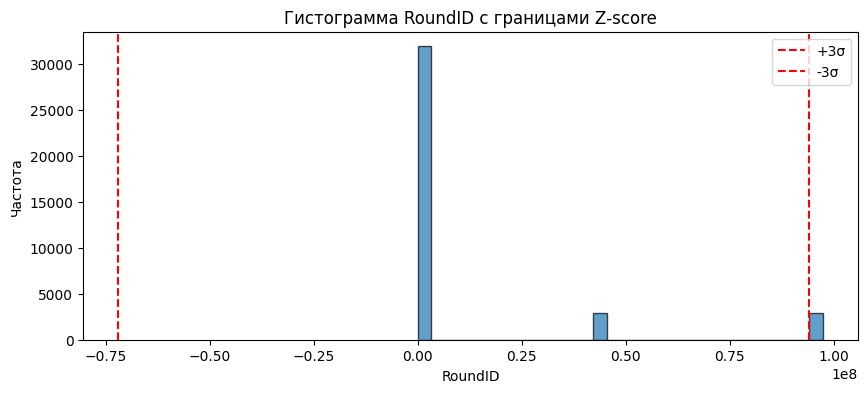


=== Метод IQR ===
Q1 = 263.00, Q3 = 255931.00, IQR = 255668.00
Нижняя граница: -383239.00, верхняя граница: 639433.00
Количество выбросов по IQR: 5887
Индексы выбросов: [25274, 25275, 25276, 25277, 25278, 25279, 25280, 25281, 25282, 25283, 25284, 25285, 25286, 25287, 25288, 25289, 25290, 25291, 25292, 25293, 25294, 25295, 25296, 25297, 25298, 25299, 25300, 25301, 25302, 25303, 25304, 25305, 25306, 25307, 25308, 25309, 25310, 25311, 25312, 25313, 25314, 25315, 25316, 25317, 25318, 25319, 25320, 25321, 25322, 25323, 25324, 25325, 25326, 25327, 25328, 25329, 25330, 25331, 25332, 25333, 25334, 25335, 25336, 25337, 25338, 25339, 25340, 25341, 25342, 25343, 25344, 25345, 25346, 25347, 25348, 25349, 25350, 25351, 25352, 25353, 25354, 25355, 25356, 25357, 25358, 25359, 25360, 25361, 25362, 25363, 25364, 25365, 25366, 25367, 25368, 25369, 25370, 25371, 25372, 25373, 25374, 25375, 25376, 25377, 25378, 25379, 25380, 25381, 25382, 25383, 25384, 25385, 25386, 25387, 25388, 25389, 25390, 25391, 253

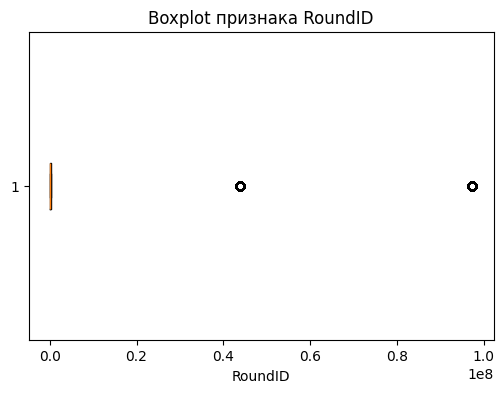


=== Сравнение методов ===
Z‑score выявил 2943 выбросов, IQR — 5887.
Различие объясняется тем, что Z‑score опирается на предположение о нормальности распределения,
а IQR более устойчив к асимметрии. Поскольку распределение RoundID не является нормальным,
метод IQR считается более надёжным для данного признака.


In [6]:




import numpy as np
import matplotlib.pyplot as plt


feature = round_id.copy()

# ------------------------------------------------------------
# 3.1 Метод Z‑score (z‑оценка)
# ------------------------------------------------------------
print("\n=== Метод Z‑score ===")


mean_val = feature.mean()
std_val = feature.std()


z_scores = (feature - mean_val) / std_val


outliers_z = feature[np.abs(z_scores) > 3]

print(f"Количество выбросов по Z-score: {len(outliers_z)}")
print(f"Индексы выбросов: {outliers_z.index.tolist()}")
print(f"Значения выбросов: {outliers_z.values}")


plt.figure(figsize=(10, 4))
plt.hist(feature, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(mean_val + 3*std_val, color='red', linestyle='--', label='+3σ')
plt.axvline(mean_val - 3*std_val, color='red', linestyle='--', label='-3σ')
plt.title('Гистограмма RoundID с границами Z‑score')
plt.xlabel('RoundID')
plt.ylabel('Частота')
plt.legend()
plt.show()

# ------------------------------------------------------------
# 3.2 Метод IQR (межквартильный размах)
# ------------------------------------------------------------
print("\n=== Метод IQR ===")


Q1 = feature.quantile(0.25)
Q3 = feature.quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = feature[(feature < lower_bound) | (feature > upper_bound)]

print(f"Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}, верхняя граница: {upper_bound:.2f}")
print(f"Количество выбросов по IQR: {len(outliers_iqr)}")
print(f"Индексы выбросов: {outliers_iqr.index.tolist()}")
print(f"Значения выбросов: {outliers_iqr.values}")


plt.figure(figsize=(6, 4))
plt.boxplot(feature, vert=False)
plt.title('Boxplot признака RoundID')
plt.xlabel('RoundID')
plt.show()

# ------------------------------------------------------------
# 3.3 Сравнение методов
# ------------------------------------------------------------
print("\n=== Сравнение методов ===")
print(f"Z‑score выявил {len(outliers_z)} выбросов, IQR — {len(outliers_iqr)}.")
print("Различие объясняется тем, что Z‑score опирается на предположение о нормальности распределения,")
print("а IQR более устойчив к асимметрии. Поскольку распределение RoundID не является нормальным,")
print("метод IQR считается более надёжным для данного признака.")

Четвертое задание. Метод локальной плотности

k = 3:
  Количество аномалий: 1332 из 37784
  Порог (95%): 0.000000



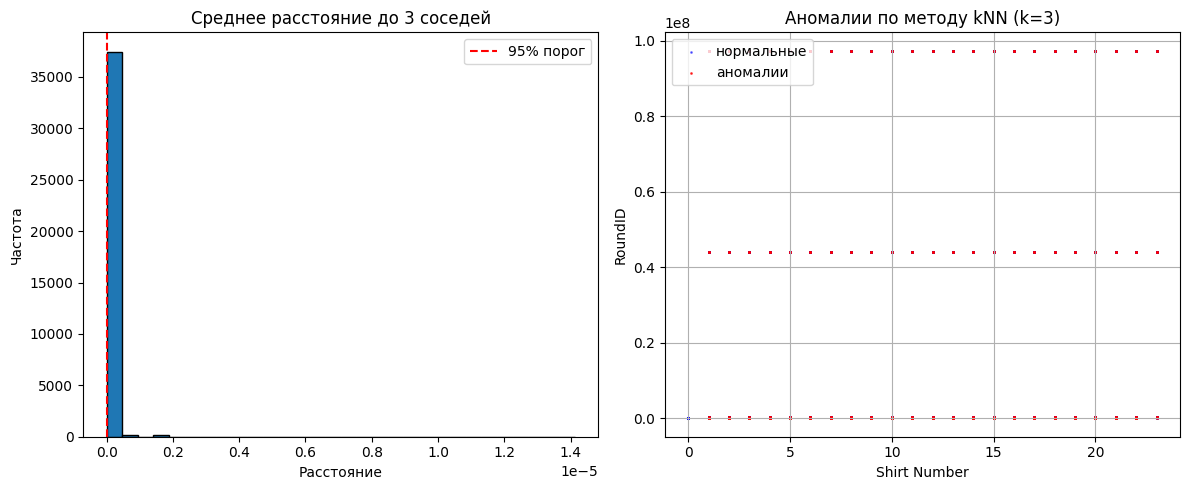

k = 5:
  Количество аномалий: 1297 из 37784
  Порог (95%): 0.000000



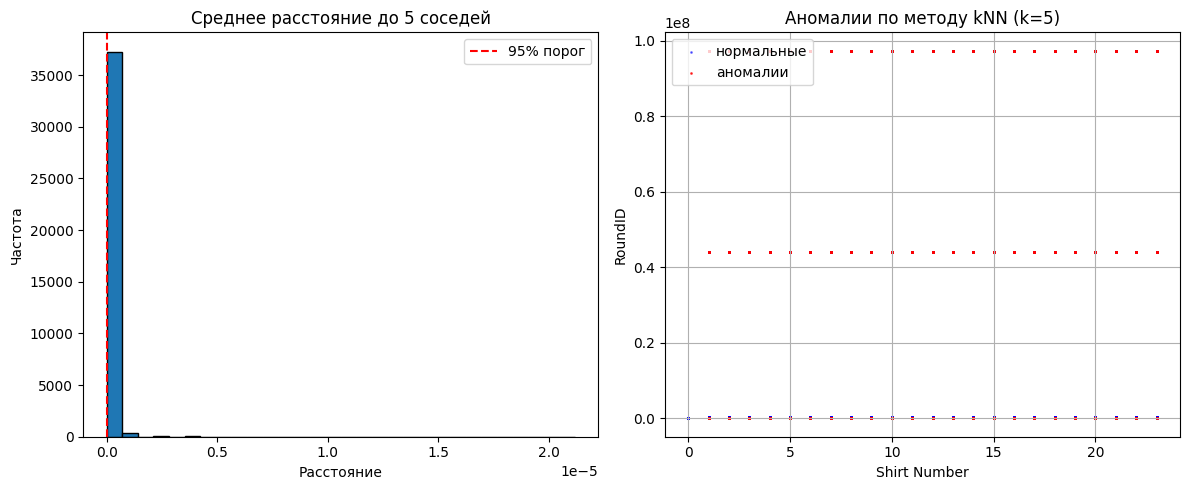

k = 7:
  Количество аномалий: 1833 из 37784
  Порог (95%): 0.000000



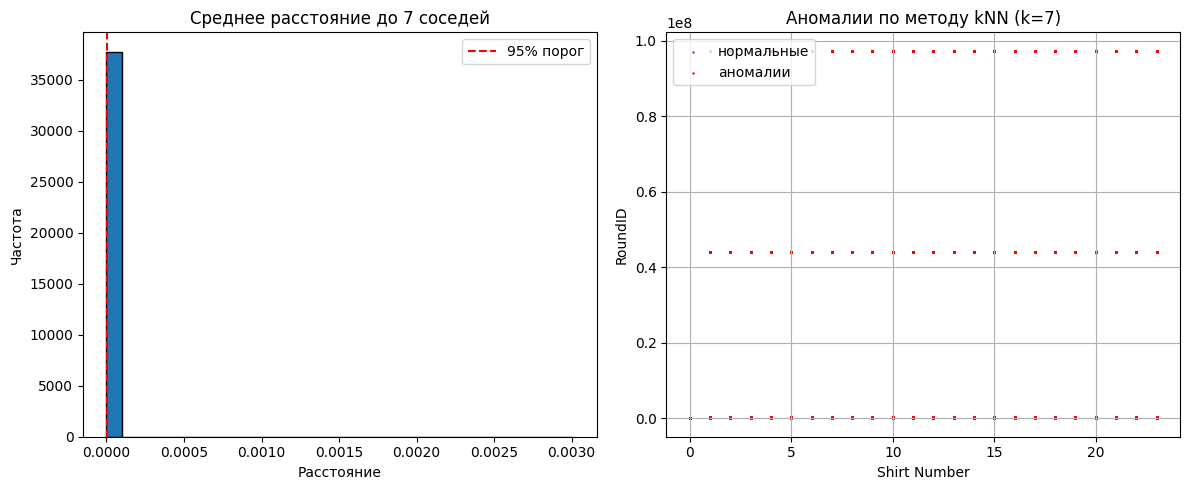

k = 9:
  Количество аномалий: 1877 из 37784
  Порог (95%): 0.000000



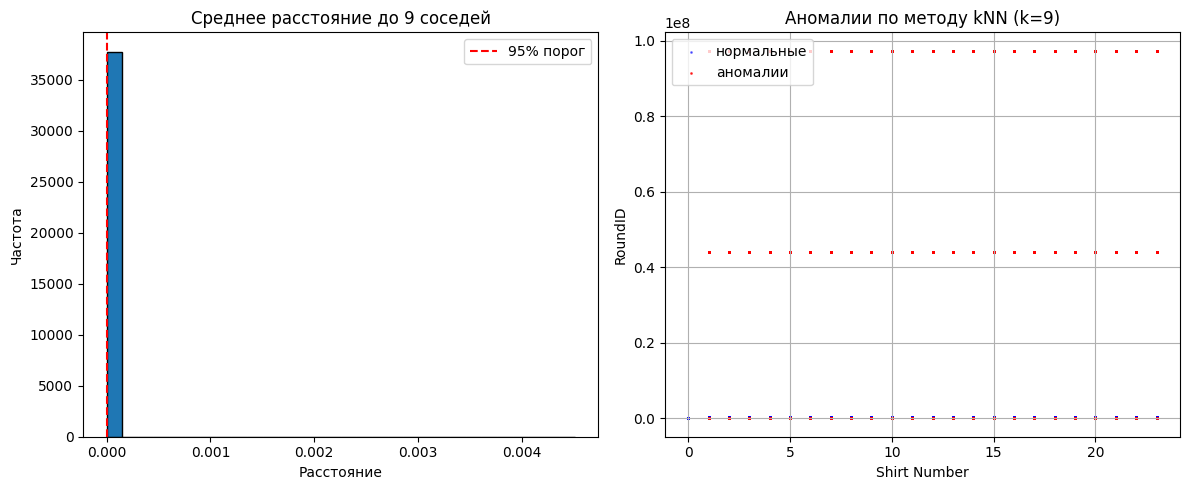


=== Сравнение результатов для разных k ===
Значения k:      3       5       7       9
Аномалий при k=3: 1332
Аномалий при k=5: 1297
Аномалий при k=7: 1833
Аномалий при k=9: 1877

Анализ:
- С ростом k среднее расстояние до соседей становится более гладким, так как учитывается больше точек.
- Количество аномалий (верхние 5%) остаётся примерно одинаковым, но сами точки могут немного отличаться.
- При малых k (3) аномалии определяются по локальной плотности; при больших k (9) учитывается более широкая окрестность, что может давать более стабильную картину.
- Визуально на scatter plot аномалии всегда располагаются в областях с низкой плотностью точек.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


X = data[['Shirt Number', 'RoundID']].values


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


def knn_mean_distance(X, k, metric='euclidean'):
    nn = NearestNeighbors(n_neighbors=k, metric=metric)
    nn.fit(X)
    distances, _ = nn.kneighbors(X)

    return distances[:, 1:].mean(axis=1)


k_values = [3, 5, 7, 9]


results = {}

for k in k_values:

    dist = knn_mean_distance(X_scaled, k, metric='euclidean')

    threshold = np.percentile(dist, 95)
    outliers = dist > threshold


    results[k] = {'dist': dist, 'threshold': threshold, 'outliers': outliers}


    print(f"k = {k}:")
    print(f"  Количество аномалий: {np.sum(outliers)} из {len(dist)}")
    print(f"  Порог (95%): {threshold:.6f}")
    print()


    plt.figure(figsize=(12, 5))


    plt.subplot(1, 2, 1)
    plt.hist(dist, bins=30, edgecolor='black')
    plt.axvline(threshold, color='red', linestyle='--', label='95% порог')
    plt.title(f'Среднее расстояние до {k} соседей')
    plt.xlabel('Расстояние')
    plt.ylabel('Частота')
    plt.legend()


    plt.subplot(1, 2, 2)
    plt.scatter(X[:, 0], X[:, 1], c='blue', label='нормальные', alpha=0.5, s=1)
    plt.scatter(X[outliers, 0], X[outliers, 1], c='red', label='аномалии', alpha=0.7, s=1)
    plt.xlabel('Shirt Number')
    plt.ylabel('RoundID')
    plt.title(f'Аномалии по методу kNN (k={k})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


print("\n=== Сравнение результатов для разных k ===")
print("Значения k:      3       5       7       9")
for k in k_values:
    cnt = np.sum(results[k]['outliers'])
    print(f"Аномалий при k={k}: {cnt}")
print()
print("Анализ:")
print("- С ростом k среднее расстояние до соседей становится более гладким, так как учитывается больше точек.")
print("- Количество аномалий (верхние 5%) остаётся примерно одинаковым, но сами точки могут немного отличаться.")
print("- При малых k (3) аномалии определяются по локальной плотности; при больших k (9) учитывается более широкая окрестность, что может давать более стабильную картину.")
print("- Визуально на scatter plot аномалии всегда располагаются в областях с низкой плотностью точек.")